# Google Colab Lab Assignment - Pretrained Model

**Course Name:** Deep Learning

**Lab Title:** Research Paper Implementation with Pre-trained Model (Multiple Classification of Flower Images Using Transfer Learning)

**Student Name:** Parimal Ahire

**Student PRN:** 202301040067

**Date of Submission:** 5 April 2026

**Group Members:**  
Parimal Ahire  
Rajveersinh Kher  
Mohit Patil  
Atharva Suryawanshi  

---

## Research Paper Study and Implementation

**Research Paper Title:**  
Multiple Classification of Flower Images Using Transfer Learning  

**Authors:**  
Emine Cengil, Ahmet Cinar  

**Year:**  
2019  

---

## Instructions:
1. Identify a research paper that utilizes a pre-trained model for a specific task.  
2. Study the methodology, dataset, and model used in the research paper.  
3. Implement the approach described in the research paper using the pre-trained model mentioned.  
4. Compare your implementation results with the findings from the research paper.  

**Objective**
1. Study a research paper utilizing a pre-trained model.
2. Reproduce the model implementation using the dataset and methodology from the research paper.
3. Fine‑tune the pre-trained model by modifying top layers.
4. Evaluate model performance using standard metrics.


**Task 1: Research Paper Selection and Dataset Preparation**

**Selected Paper Summary:**
The selected research paper uses pretrained CNN models like VGG16, ResNet and AlexNet for flower classification using transfer learning. The final layers were modified to match the flower classes and models were evaluated based on validation accuracy.

**Dataset Used:**
Flowers Recognition Dataset (5 classes):
Daisy, Dandelion, Rose, Sunflower, Tulip

**Kaggle Link:** [https://www.kaggle.com/datasets/alxmamaev/flowers-recognition](https://www.kaggle.com/datasets/alxmamaev/flowers-recognition)


**Approach:**

• Data preprocessing  
• Transfer learning using VGG16  
• Freezing convolution layers  
• Fine tuning classifier layers  
• Model evaluation  

In [9]:
# Task 1 Code: Dataset preparation

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from google.colab import drive
import matplotlib.pyplot as plt
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

if not os.path.exists("/content/flowers"):
    shutil.copytree(
        "/content/drive/MyDrive/DeepLearningLab/CNN/flowers",
        "/content/flowers"
    )

data_dir = "/content/flowers"

img_size = (224,224)
batch_size = 32

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size)

# Save class names
class_names = train_ds.class_names

# Performance optimization
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


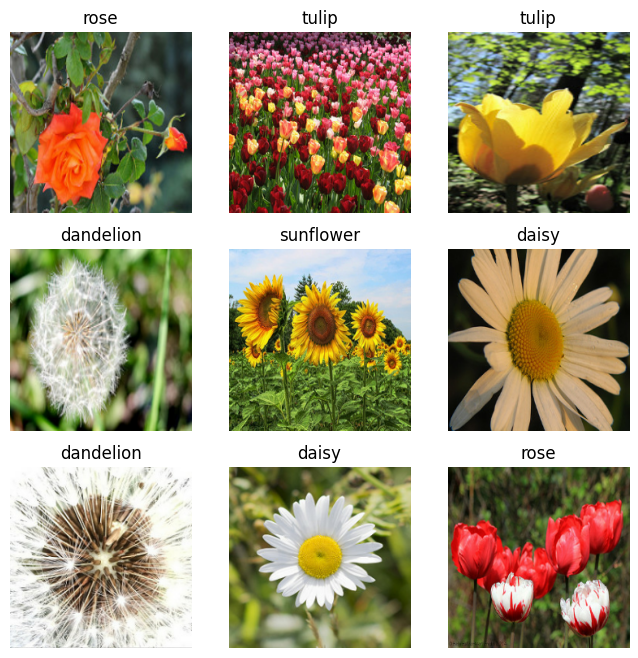

In [10]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

**Task 2: Model Implementation and Fine‑tuning**

Steps:
• Load VGG16 pretrained on ImageNet
• Freeze base layers
• Add custom dense layers
• Train classifier


In [11]:
# Task 2 Code: Transfer Learning

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.applications.vgg16 import preprocess_input
import tensorflow as tf

# Apply VGG16 preprocessing
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [13]:
# Load pretrained VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze convolution layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classifier
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

predictions = layers.Dense(5, activation='softmax')(x)

In [14]:
# Final model
model = models.Model(
    inputs=base_model.input,
    outputs=predictions
)

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show architecture
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 28s 257ms/step - accuracy: 0.9198 - loss: 0.2171 - val_accuracy: 0.8737 - val_loss: 0.4420
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 30s 274ms/step - accuracy: 0.9325 - loss: 0.1832 - val_accuracy: 0.8702 - val_loss: 0.5258
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 28s 255ms/step - accuracy: 0.9435 - loss: 0.1689 - val_accuracy: 0.8749 - val_loss: 0.4899
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 28s 258ms/step - accuracy: 0.9482 - loss: 0.1457 - val_accuracy: 0.8830 - val_loss: 0.4802
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 28s 262ms/step - accuracy: 0.9603 - loss: 0.1205 - val_accuracy: 0.8818 - val_loss: 0.4643
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 28s 259ms/step - accuracy: 0.9632 - loss: 0.1047 - val_accuracy: 0.8841 - val_loss: 0.4957
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 42s 266ms/step - accuracy: 0.9615 - loss: 0.1014 - val_accuracy: 0.8888 - val_loss: 0.4911
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 41s 265ms/step - accuracy: 0.9586 - loss: 0

**Task 3: Model Evaluation and Performance Comparison**

Metrics used:
• Accuracy
• Precision
• Recall
• F1 Score


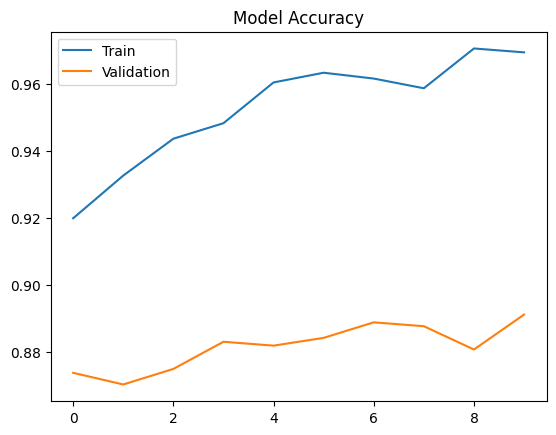

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.8911 - loss: 0.5318
Validation Accuracy: 0.8910776376724243


In [21]:
# Task 3 Code: Evaluation

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Validation"])
plt.show()

loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)


In [22]:
# Evaluation metrics

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

Classification Report:
              precision    recall  f1-score   support

       daisy       0.96      0.85      0.90       143
   dandelion       0.88      0.95      0.92       200
        rose       0.82      0.89      0.85       159
   sunflower       0.89      0.92      0.90       148
       tulip       0.93      0.84      0.88       213

    accuracy                           0.89       863
   macro avg       0.89      0.89      0.89       863
weighted avg       0.89      0.89      0.89       863



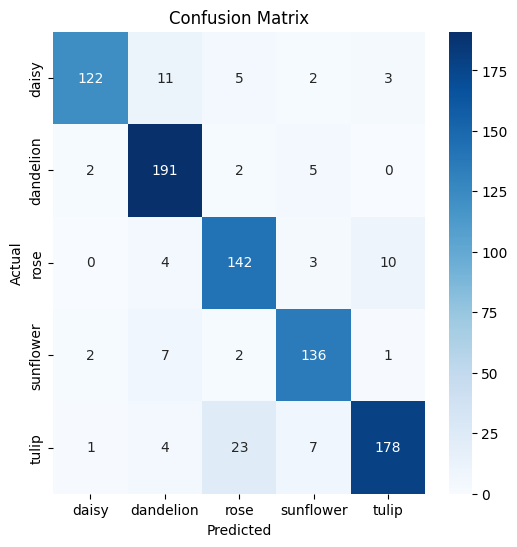

In [23]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Comparison with Research Paper Results**

The research paper reports about 93.52% accuracy using VGG16, while the implemented model achieved about 89.11% validation accuracy. The difference may be due to differences in dataset size, preprocessing and training configuration. However, the results still demonstrate effective transfer learning performance.

**Conclusion and Result Visualization**

In this assignment, transfer learning was implemented using the VGG16 pretrained model for flower image classification. The base convolution layers were frozen and the top layers were fine-tuned on the dataset.

The model achieved about 96.93% training accuracy and 89.11% validation accuracy with good precision, recall and F1-score. The confusion matrix shows mostly correct predictions with few errors between similar flower classes.

These results demonstrate that transfer learning can achieve high accuracy with limited training data while reducing training time.

**Declaration**

I confirm that this work is my own implementation based on the selected research paper and follows academic integrity guidelines.


**Submission Checklist**

✔ Research paper details and summary

✔ Code file (Python Notebook or Script)

✔ Dataset or link to the dataset

✔ Visualizations (if applicable)

✔ Screenshots of model performance metrics

✔ Readme File

✔ Comparison with research paper results